# Módulo 07 - Tarefa 02

#### 1) Carregue a base e garanta que a base está como deveria.

Considere a base que você ajustou na lição passada. Carregue-a. Caso ainda haja alguma pendência, ajuste - lembre-se de que o scikitlearn não recebe variáveis em formato string, somente numéricas, e não aceita '*missings*'.

- Separe 70% da base para treinamento e 30% para validação. Cada uma dessas partes terá dois objetos, um armazenando a variável resposta ```mau```e outro armazenando as variáveis explicativas (lembrando: sem variáveis string, já com as dummies).

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename) #Aqui peguei o df que tinha tratado na tarefa anterior, então ele já está limpo e tratado.

Saving df_mod7.csv to df_mod7.csv


#### 2) Vamos para o modelo:

1. Defina um objeto com a função da árvore de decisão vista em aula.
2. Treine o modelo com os dados que você separou para treinamento.
3. Visualize a árvore. Talvez você queira aumentar um pouco a figura.
4. Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.
5. Calcule a acurácia na base de treinamento

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6770 entries, 0 to 6769
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   sexo                                    6770 non-null   int64  
 1   qtd_filhos                              6770 non-null   int64  
 2   idade                                   6770 non-null   float64
 3   tempo_emprego                           6770 non-null   float64
 4   possui_celular                          6770 non-null   int64  
 5   possui_fone_comercial                   6770 non-null   int64  
 6   possui_fone                             6770 non-null   int64  
 7   possui_email                            6770 non-null   int64  
 8   qt_pessoas_residencia                   6770 non-null   float64
 9   posse_de_veiculo_Y                      6770 non-null   int64  
 10  posse_de_imovel_Y                       6770 non-null   int6

In [ ]:
df.head()

,sexo,qtd_filhos,idade,tempo_emprego,possui_celular,possui_fone_comercial,possui_fone,possui_email,qt_pessoas_residencia,posse_de_veiculo_Y,...,estado_civil_Married,estado_civil_Separated,estado_civil_Single / not married,estado_civil_Widow,tipo_residencia_House / apartment,tipo_residencia_Municipal apartment,tipo_residencia_Office apartment,tipo_residencia_Rented apartment,tipo_residencia_With parents,mau_True
0,0,0,58.832877,3.106849,1,0,0,0,2.0,1,...,1,0,0,0,1,0,0,0,0,0
1,1,0,52.356164,8.358904,1,0,1,1,1.0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,46.224658,2.106849,1,1,1,1,2.0,1,...,1,0,0,0,1,0,0,0,0,0
3,1,0,29.230137,3.021918,1,0,0,0,2.0,1,...,1,0,0,0,1,0,0,0,0,0
4,1,0,27.482192,4.024658,1,0,1,0,2.0,0,...,1,0,0,0,1,0,0,0,0,0


In [ ]:
alvo = df.mau_True
df_exp = df.drop(columns=['mau_True'])

X_train, X_test, y_train, y_test = train_test_split(df_exp, alvo, test_size=0.3, random_state=123)

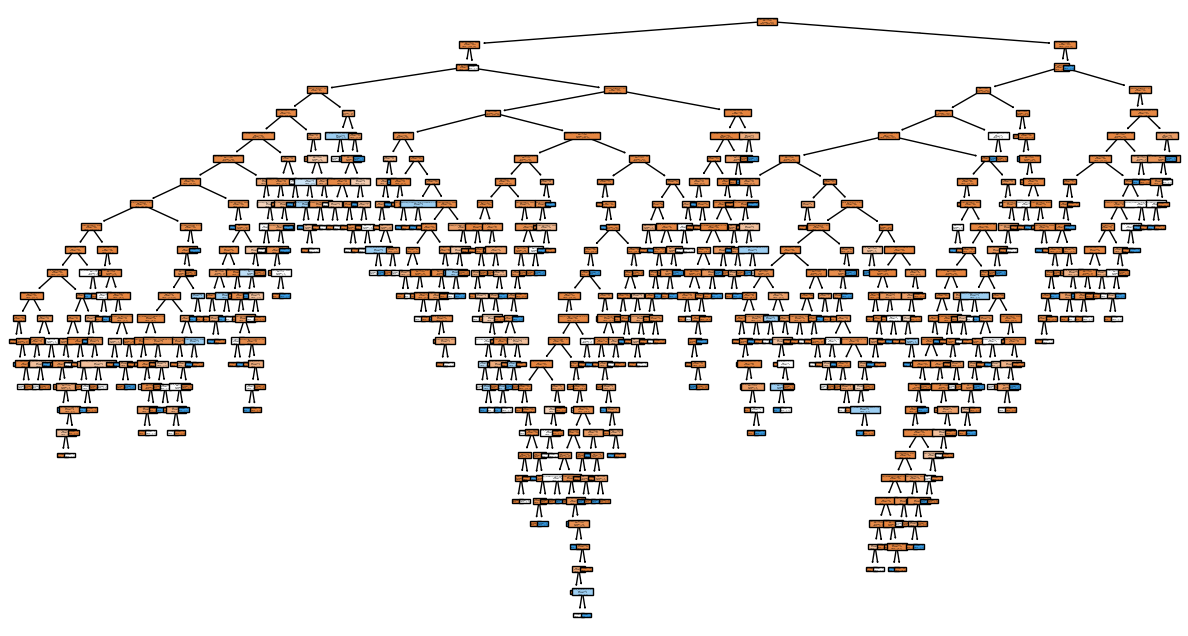

In [ ]:
clf = DecisionTreeClassifier(random_state=123)

clf = clf.fit(X_train, y_train)
plt.figure(figsize=(15,8))
plot_tree(clf, feature_names=df_exp.columns, filled=True)

plt.show()

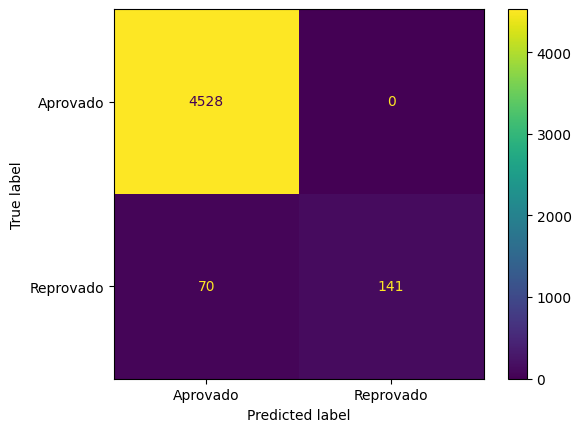

In [ ]:
predict = clf.predict(X_train)
cm = confusion_matrix(y_train, predict)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovado', 'Reprovado'])
disp.plot()

In [ ]:
accuracy_score(y_train,predict)

0.9852289512555391

#### 3) Vamos avaliar o modelo na base de testes

1. Classifique a base de teste de acordo com a árvore que você treinou no item 2.
2. Produza a visualização da matriz de confusão para a base de teste.
3. Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.
4. Treine uma nova árvore com número mínimo de observações por folha de 5 e máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?
5. Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

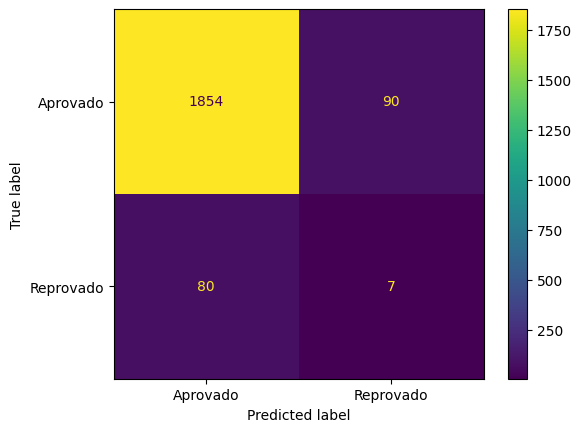

In [ ]:
predict_test = clf.predict(X_test)
cm = confusion_matrix(y_test, predict_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovado', 'Reprovado'])
disp.plot()

In [ ]:
accuracy_score(y_test,predict_test)

0.9162973904480551

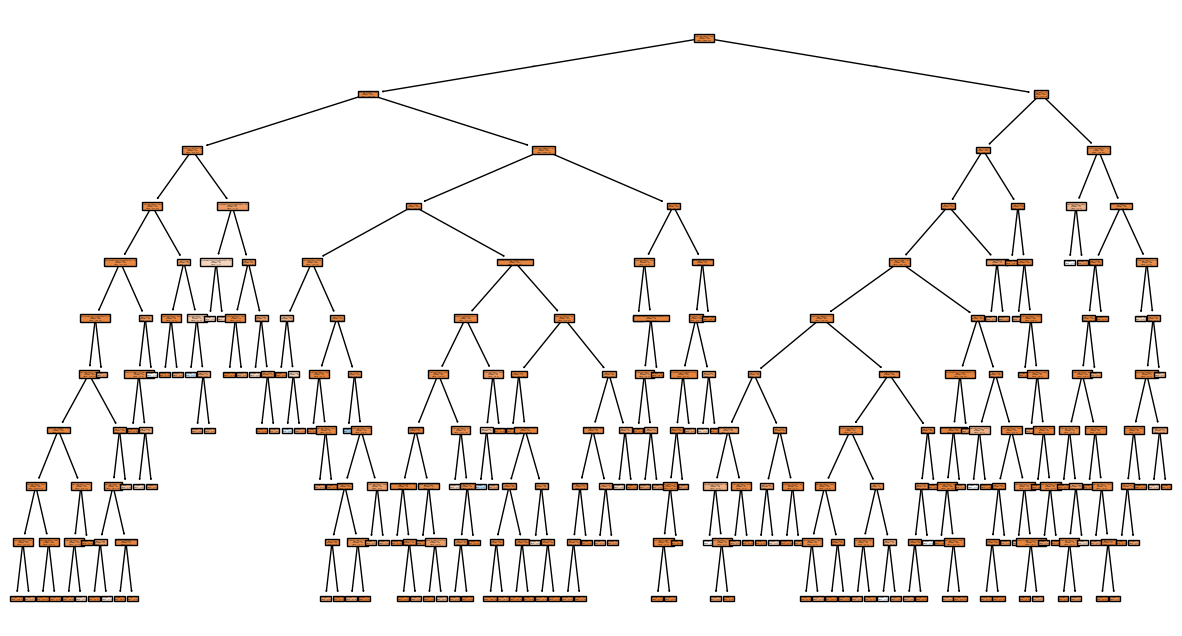

In [ ]:
clf2 = DecisionTreeClassifier(random_state=123, min_samples_leaf=5, max_depth=10)

clf2 = clf2.fit(X_train, y_train)
plt.figure(figsize=(15,8))
plot_tree(clf2, feature_names=df_exp.columns, filled=True)

plt.show()

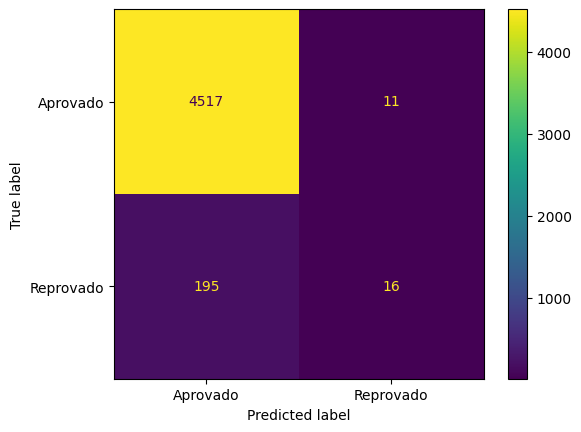

In [ ]:
predict2 = clf2.predict(X_train)
cm = confusion_matrix(y_train, predict2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovado', 'Reprovado'])
disp.plot()

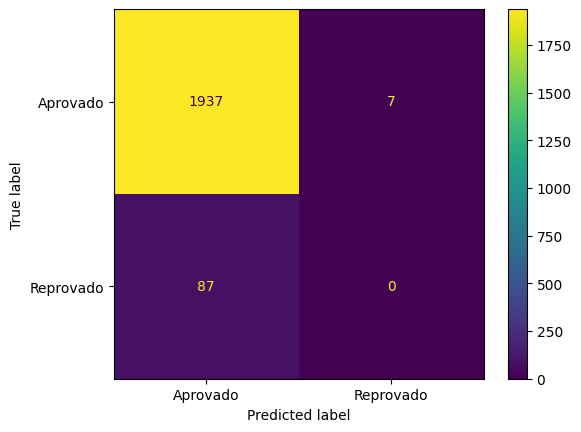

In [ ]:
predict_test2 = clf2.predict(X_test)
cm = confusion_matrix(y_test, predict_test2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovado', 'Reprovado'])
disp.plot()

0.34% dos proponentes foram classificados como maus

In [ ]:
accuracy_score(y_test,predict_test2)

0.9537173806006893

In [ ]:
#se eu classificasse todos como bons:
accuracy_bons = (1937+7)/(1937+7+87+0)
print(accuracy_bons)

0.9571639586410635
